In [1]:
import scanpy as sc
import anndata as ad
import hdf5plugin
import os
import numpy as np
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# --- Configuration ---
main_path = r"Z:\selim_working_dir\2025_sato_anestacia_circadian_rhythm\scanpy_analysis"
os.chdir(main_path)
print(f"Current Working Directory set to: {os.getcwd()}")

# File names (now relative to CWD)
FILE_NAME = 'sato_mouse_breast_cancer_circadian_tcells_only_raw.h5ad' # Raw to normalize in this pipeline
#FILE_NAME = 'sato_mouse_breast_cancer_circadian_tcells_only.h5ad' # Normalized globally with the rest of cell types
fname_filtered = FILE_NAME
adata = sc.read_h5ad(fname_filtered)
adata

Current Working Directory set to: Z:\selim_working_dir\2025_sato_anestacia_circadian_rhythm\scanpy_analysis


AnnData object with n_obs × n_vars = 11996 × 19000
    obs: 'cell_type', 'batch_id', 'cluster', 'tumor_state_scevan', 'subclone_state_scevan', 'sample_description', 'tumor_stage', 'sample_id_original', 'batch', 'ZT_time', 'broad_cell_types', 'sub_cell_types'
    obsm: 'X_umap'

In [7]:
# If raw data, then normalize.
# 3.1 Normalize and Log-Transform
# This overwrites adata.X with the normalized, log-transformed data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

PCA analysis (n_comps=50)...


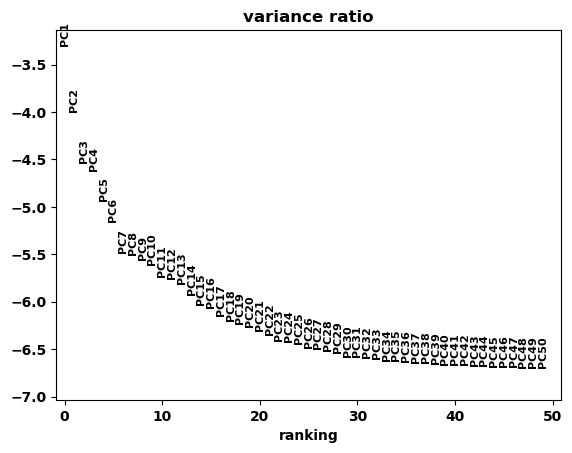

In [8]:
#sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="batch_id")# Flavor seurat
sc.pp.highly_variable_genes(adata, n_top_genes=2000)# Flavor seurat
#sc.pl.highly_variable_genes(adata, save="_hvgs_mean_disper.svg")
npca = 50

use_hvg = adata.var['highly_variable'].sum() > 0
if adata.n_obs > 20000:
    print(f"PCA analysis in chunks of 10000 cells (n_comps={npca})...")
    sc.tl.pca(adata, n_comps=npca, mask_var="highly_variable", chunked=True, chunk_size=10000, svd_solver="arpack")
else:
    print(f"PCA analysis (n_comps={npca})...")
    sc.tl.pca(adata, n_comps=npca, mask_var="highly_variable", chunked=False, svd_solver="arpack")

sc.pl.pca_variance_ratio(adata, n_pcs=npca, log=True)

In [9]:
# --- Custom Parameters ---
ndim = 2           # Number of UMAP dimensions
n_neighbors = 15   # Number of neighbors for the graph
my_res = 1.0       # Clustering resolution (changed from 2.0 to 1.0 as requested)
algo_cluster = "leidenalg"

# 5. Neighbors and UMAP (Step 8)
# This step uses the 50-component PCA result (adata.obsm['X_pca'])
print(f"Computing nearest neighbors (k={n_neighbors}) and UMAP (n_dims={ndim})...")
sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=npca)
sc.tl.umap(adata, n_components=ndim)

# 6. Global Leiden Clustering (Replacing Batch-Aware Clustering)
# This runs Leiden once on the entire graph structure computed from the 50 PCs.
cluster_key = f'leiden_global_{my_res}' # Renamed key to reflect global clustering
print(f"\nComputing **Global** Leiden clusters (res={my_res}, flavor={algo_cluster}) on all {adata.n_obs} cells...")

sc.tl.leiden(
    adata,
    flavor=algo_cluster,
    n_iterations=2, # Use n_iterations=2 as in the previous code
    resolution=my_res,
    key_added=cluster_key
)


Computing nearest neighbors (k=15) and UMAP (n_dims=2)...

Computing **Global** Leiden clusters (res=1.0, flavor=leidenalg) on all 11996 cells...


Global Leiden clustering complete. Results in adata.obs['leiden_global_1.0']

Plotting UMAP colored by leiden_global_1.0 and saving...


[<Axes: title={'center': 'leiden_global_1.0'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'broad_cell_types'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'sub_cell_types'}, xlabel='UMAP1', ylabel='UMAP2'>]

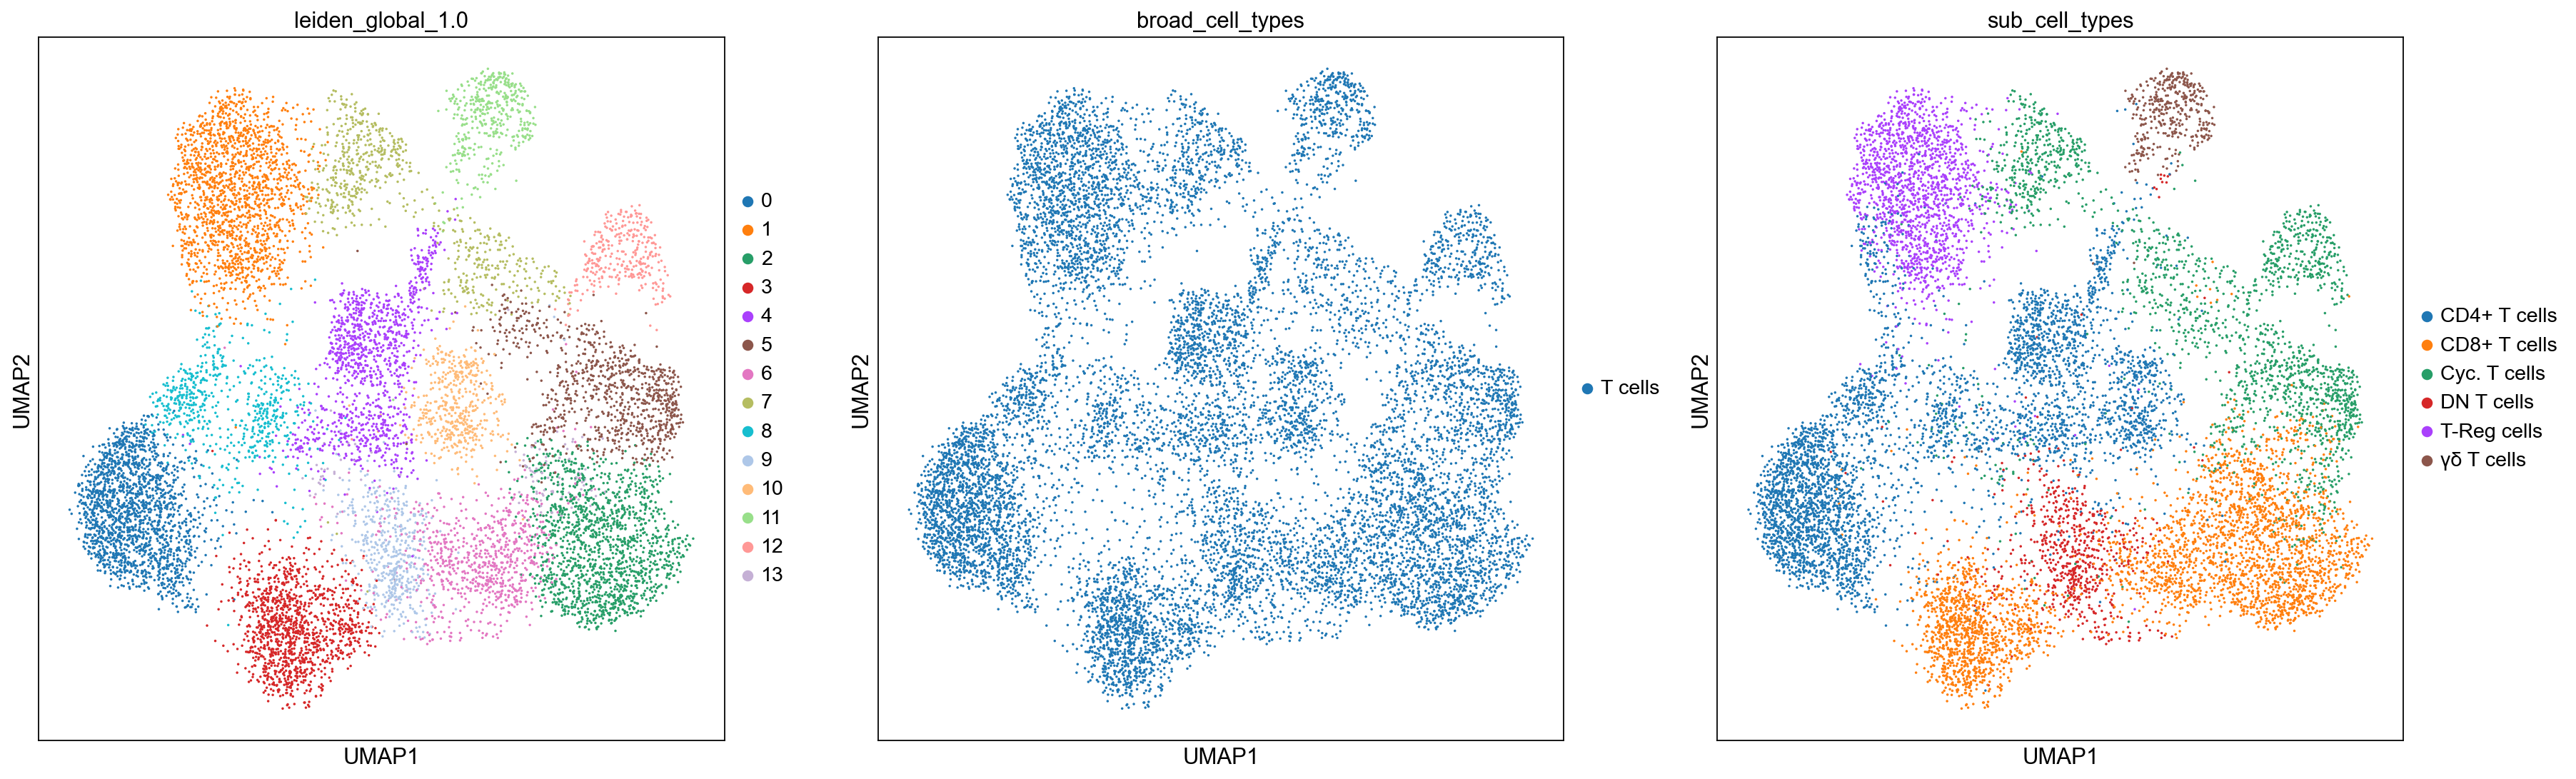

In [11]:
print(f"Global Leiden clustering complete. Results in adata.obs['{cluster_key}']")

# 7. Plot and Save UMAP
print(f"\nPlotting UMAP colored by {cluster_key} and saving...")
sc.set_figure_params(figsize=(8, 8)) 
sc.pl.umap(adata, color=[cluster_key, 'broad_cell_types', 'sub_cell_types'], show=False)
# The final H5AD save (Step 8) will automatically include all new results.

In [13]:
adata.obs['tumor_stage'].unique()

['Intermediate', 'Early', 'Advanced']
Categories (3, object): ['Advanced', 'Early', 'Intermediate']

In [15]:
import pandas as pd
import numpy as np
import scanpy as sc
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Data Preparation: Ensure 'adata' is loaded and ready ---
def prepare_gene_expression_data(adata, min_cells_frac=0.1):
    """
    Extracts the gene expression matrix from the AnnData object and
    converts it into a pandas DataFrame (genes x cells).
    Filters for genes expressed in at least min_cells_frac fraction of cells.
    """
    # Convert to dense matrix if needed
    if hasattr(adata.X, 'toarray'):
        gene_expression_matrix = adata.X.T.toarray()
    else:  # assuming it's already a dense numpy array
        gene_expression_matrix = adata.X.T

    # Create DataFrame (Genes as index, Cells as columns)
    gene_expression_df = pd.DataFrame(
        gene_expression_matrix,
        index=adata.var_names,
        columns=adata.obs_names
    )

    # Filter genes: keep those expressed in at least min_cells_frac of cells
    # (expression > 0)
    cell_count = gene_expression_df.shape[1]
    min_cells = int(np.ceil(min_cells_frac * cell_count))

    # Sum across columns (cells), get how many cells each gene is expressed in
    expressed_in_cells = (gene_expression_df > 0).sum(axis=1)

    # Filter
    filtered_gene_expression_df = gene_expression_df.loc[expressed_in_cells >= min_cells]

    print(f"Filtered genes from {gene_expression_df.shape[0]} to {filtered_gene_expression_df.shape[0]}")
    return filtered_gene_expression_df

# --- 2. Correlation and Adjacency Matrix Calculation ---
def calculate_correlation_and_adjacency(gene_expression_df, method, threshold=0.5):
    """
    Calculates the gene-gene correlation matrix and an adjacency matrix
    based on a given absolute correlation threshold.
    methods ----> 'pearson', 'kendall', 'spearman' (str)
    """
    # Calculate the correlation matrix (Cells as rows, Genes as columns for correlation)
    # df.T ensures we correlate genes across cells
    corr_matrix = gene_expression_df.T.corr(method=method)

    # Filter for strong correlations to create the adjacency matrix.
    adj_matrix = np.where(np.abs(corr_matrix.values) > threshold, corr_matrix.values, 0)
    # Remove self-loops (correlation of a gene with itself)
    np.fill_diagonal(adj_matrix, 0)
    non_zero_count = np.count_nonzero(adj_matrix)
    print(f"Number of non-zero elements (connections): {non_zero_count}")
    
    return corr_matrix.index, adj_matrix

def calculate_correlation_and_adjacency_top_percent(gene_expression_df, method, top_percent=0.05):
    """
    Calculates the gene-gene correlation matrix and an adjacency matrix,
    keeping only the top_percent strongest (absolute-value) links.
    """
    corr_matrix = gene_expression_df.T.corr(method=method)
    abs_corr = np.abs(corr_matrix.values)

    # Flatten, sort, get the cutoff
    all_corrs = abs_corr.flatten()
    valid_corrs = all_corrs[all_corrs != 1]    # Exclude diagonal/self-correlation
    cutoff = np.percentile(valid_corrs, 100*(1-top_percent))

    adj_matrix = np.where(abs_corr > cutoff, corr_matrix.values, 0)
    np.fill_diagonal(adj_matrix, 0)

    non_zero_count = np.count_nonzero(adj_matrix)
    print(f"Threshold for top {int(top_percent*100)}% links: {cutoff:.3f}")
    print(f"Number of top edges retained: {non_zero_count}")

    return corr_matrix.index, adj_matrix

# --- 3. Network Graph Construction and Plotting Function (UPDATED) ---
def plot_correlation_network(adj_matrix, gene_names, title_suffix, num_nodes=20, figsize=(6, 5), filename=None):
    """
    Constructs a NetworkX graph, extracts a sub-network, plots the result,
    and optionally saves the figure.
    
    Args:
        adj_matrix (np.ndarray): The gene-gene adjacency matrix.
        gene_names (pd.Index): The list of gene names.
        title_suffix (str): The correlation method (e.g., 'Pearson').
        num_nodes (int): The number of top-connected genes to plot.
        figsize (tuple): The size of the output figure (width, height).
        filename (str, optional): Filename to save the plot (e.g., 'pearson_network.png'). 
                                   If None, the figure is only displayed.
    """
    # Create a graph object from the adjacency matrix
    G = nx.from_numpy_array(adj_matrix)

    # Map the integer indices back to gene names
    mapping = {i: gene_names[i] for i in range(len(gene_names))}
    G = nx.relabel_nodes(G, mapping)

    # Remove nodes that have no connections (isolated genes)
    G.remove_nodes_from(list(nx.isolates(G)))

    # Find the top 'num_nodes' most highly connected genes
    degrees = dict(G.degree())
    most_connected_genes = sorted(degrees, key=degrees.get, reverse=True)[:num_nodes]
    subgraph = G.subgraph(most_connected_genes)

    # Set a layout for visualization
    subgraph_pos = nx.fruchterman_reingold_layout(subgraph, seed=42)

    # Plotting: Figure size is now an argument input
    plt.figure(figsize=figsize)
    nx.draw(subgraph,
            pos=subgraph_pos,
            with_labels=True,
            node_size=300,# INCREASE THIS VALUE to make nodes larger
            font_size=10,# INCREASE THIS VALUE to make gene labels larger
            font_color='black',
            node_color='skyblue',
            edge_color='gray',
            width=0.5)
    
    plt.title(f"Gene Correlation Network ({title_suffix}): Top {len(subgraph.nodes)} Genes", fontsize=10)

    # Save the file if a filename is provided (New Feature)
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved figure to {filename}")

    plt.show()

In [16]:
# We will work on this sub population of T cells
idx = adata.obs['sub_cell_types'] == "CD8+ T cells"
adata_cd8_tcells = adata[idx, :].copy()
adata_cd8_tcells

AnnData object with n_obs × n_vars = 3267 × 19000
    obs: 'cell_type', 'batch_id', 'cluster', 'tumor_state_scevan', 'subclone_state_scevan', 'sample_description', 'tumor_stage', 'sample_id_original', 'batch', 'ZT_time', 'broad_cell_types', 'sub_cell_types', 'leiden_global_1.0'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden_global_1.0', 'leiden_global_1.0_colors', 'broad_cell_types_colors', 'sub_cell_types_colors'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

Processing stage: Intermediate
Filtered genes from 19000 to 6708
Threshold for top 5% links: 0.069
Number of top edges retained: 2249530


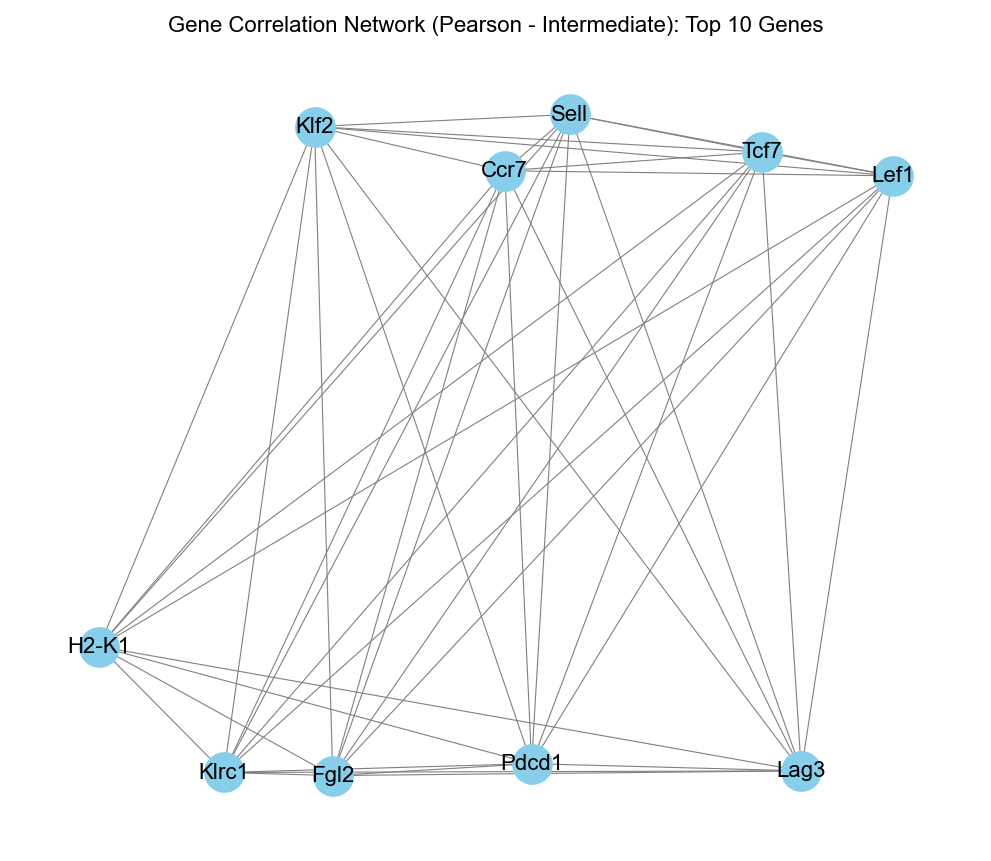

Processing stage: Early
Filtered genes from 19000 to 5948
Threshold for top 5% links: 0.089
Number of top edges retained: 1768638


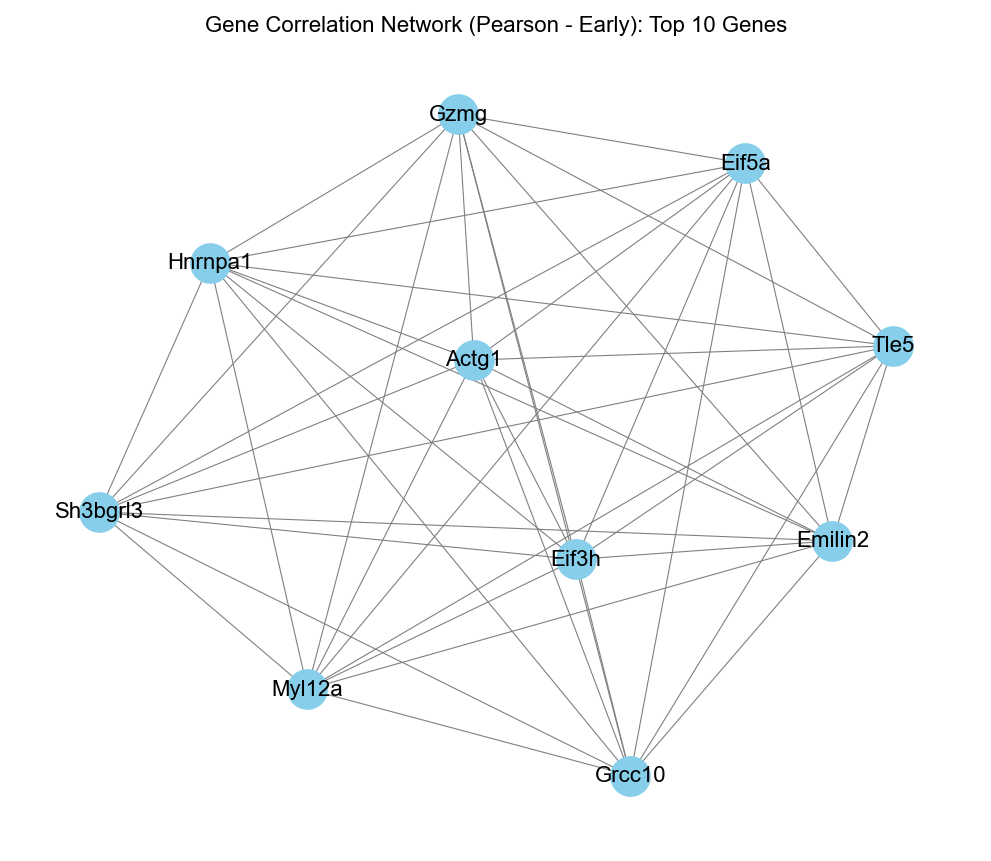

Processing stage: Advanced
Filtered genes from 19000 to 7193
Threshold for top 5% links: 0.077
Number of top edges retained: 2586602


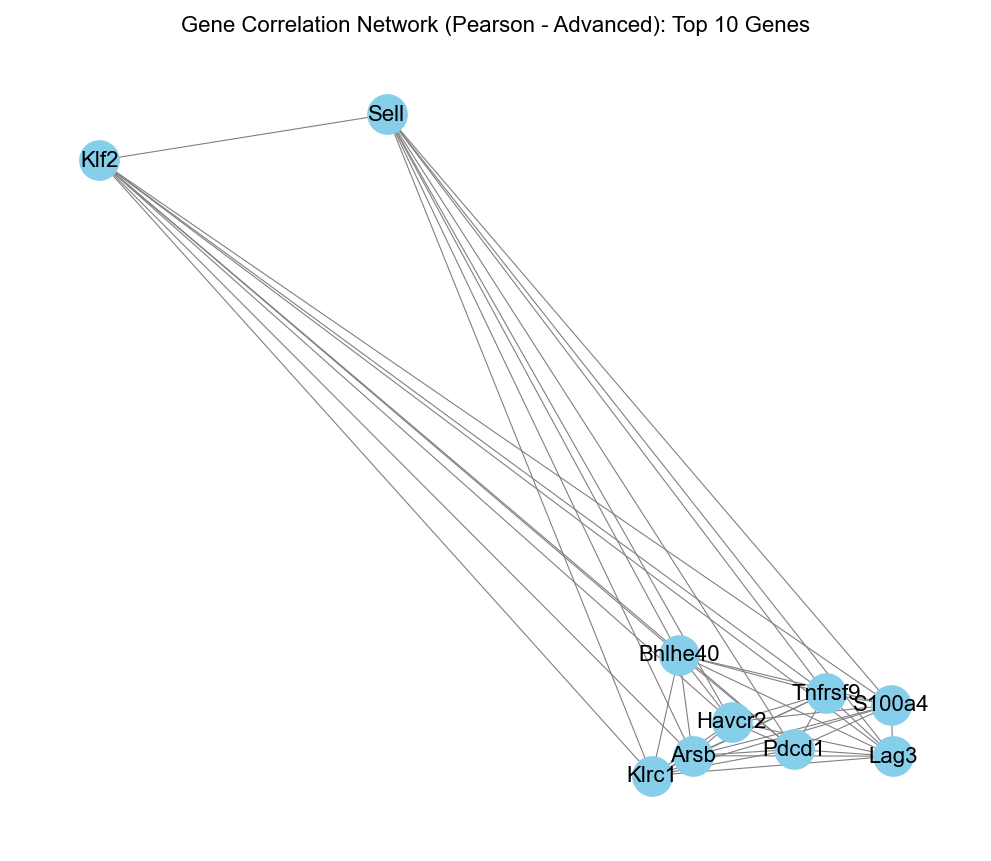

In [17]:
cancer_stages = adata_cd8_tcells.obs['tumor_stage'].unique()
# GRN from co-expressions
method = 'pearson'
for istage in cancer_stages:
    print(f"Processing stage: {istage}")
    idx = adata_cd8_tcells.obs['tumor_stage'] == istage
    adata_cd8_tcells_istage = adata_cd8_tcells[idx, :].copy()
    
    gene_expression_df = prepare_gene_expression_data(adata_cd8_tcells_istage, min_cells_frac=0.1)
    
    #gene_names, adj_matrix = calculate_correlation_and_adjacency(gene_expression_df, method, threshold=0.5)
    gene_names, adj_matrix = calculate_correlation_and_adjacency_top_percent(gene_expression_df, method="pearson", top_percent=0.05)
    
    title_suffix = f"{method.capitalize()} - {istage}"
    plot_correlation_network(adj_matrix, gene_names, title_suffix, num_nodes=10, figsize=(6, 5) )

In [18]:
import pandas as pd
import numpy as np
from arboreto.algo import grnboost2
from arboreto.utils import load_tf_names
from dask.distributed import Client
import psutil

# ---- Dask client: physical cores minus 2 ----
n_cores = max(psutil.cpu_count(logical=False) - 2, 1)
client = Client(n_workers=n_cores, threads_per_worker=1, processes=True)
print(f"Using {n_cores} Dask workers/procs (out of {psutil.cpu_count(logical=False)})")

# ---- Load TFs (mouse) ----
tf_names = load_tf_names('allTFs_mm.txt')  # TF list (one gene symbol per line)

def prepare_gene_expression_data2(adata, min_cells_frac=0.1):
    if hasattr(adata.X, "toarray"):
        m = adata.X.T.toarray()
    else:
        m = adata.X.T
    df = pd.DataFrame(m, index=adata.var_names, columns=adata.obs_names)
    n_cells = df.shape[1]
    min_cells = int(np.ceil(min_cells_frac * n_cells))
    df = df.loc[(df > 0).sum(axis=1) >= min_cells]
    return df

# ---- Compute GRNBoost2 networks for each stage ----
networks = {}  # Save each stage's network DataFrame

for istage in adata_cd8_tcells.obs['tumor_stage'].unique():
    print(f"\nProcessing stage: {istage}")
    idx = adata_cd8_tcells.obs['tumor_stage'] == istage
    adata_stage = adata_cd8_tcells[idx, :].copy()
    gene_expression_df = prepare_gene_expression_data2(adata_stage, min_cells_frac=0.1)

    # Make sure all TFs are present as rows (add zeroes if missing)
    tf_in_data = set(tf_names) & set(gene_expression_df.index)
    missing_tfs = set(tf_names) - tf_in_data
    for tf in missing_tfs:
        gene_expression_df.loc[tf] = 0

    # cells x genes
    ex_matrix = gene_expression_df.T
    ex_matrix = ex_matrix.loc[:, ~ex_matrix.columns.duplicated()]
    ex_matrix = ex_matrix.fillna(0)
    ex_matrix.columns = ex_matrix.columns.astype(str)

    valid_tfs = [tf for tf in tf_names if tf in ex_matrix.columns]
    print("Shape of ex_matrix:", ex_matrix.shape)
    print("Number of TFs in matrix:", len(valid_tfs))
    if len(valid_tfs) == 0:
        print("No valid TFs for this stage, skipping.")
        continue

    # ---- Run GRNBoost2 and store in dict ----
    network = grnboost2(
        expression_data=ex_matrix,
        tf_names=valid_tfs,
        gene_names=list(ex_matrix.columns),
        client_or_address=client
    )
    print("Top edges:")
    print(network.sort_values('importance', ascending=False).head(10))
    networks[istage] = network  # Save for later

print("\nAll networks computed and stored in networks{}.")


Using 12 Dask workers/procs (out of 14)

Processing stage: Intermediate
Shape of ex_matrix: (1342, 7904)
Number of TFs in matrix: 1860


c:\Local_install\miniconda3\envs\pyscenic\lib\site-packages\distributed\client.py:3163: UserWarning: Sending large graph of size 72.17 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Top edges:
        TF  target  importance
442    Id2   Klrc1   20.003725
295   Klf2    Sell   18.088972
397   Tcf7    Sell   16.713855
295   Klf2     Id2   16.378662
295   Klf2   Klrc1   16.170175
295   Klf2   S1pr1   14.965117
295   Klf2  Ripor2   14.953422
295   Klf2    Lag3   14.552246
574  Runx2    Klf2   13.283133
295   Klf2    Tcf7   12.954238

Processing stage: Early
Shape of ex_matrix: (748, 7241)
Number of TFs in matrix: 1860


c:\Local_install\miniconda3\envs\pyscenic\lib\site-packages\distributed\client.py:3163: UserWarning: Sending large graph of size 37.12 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


KeyboardInterrupt: 

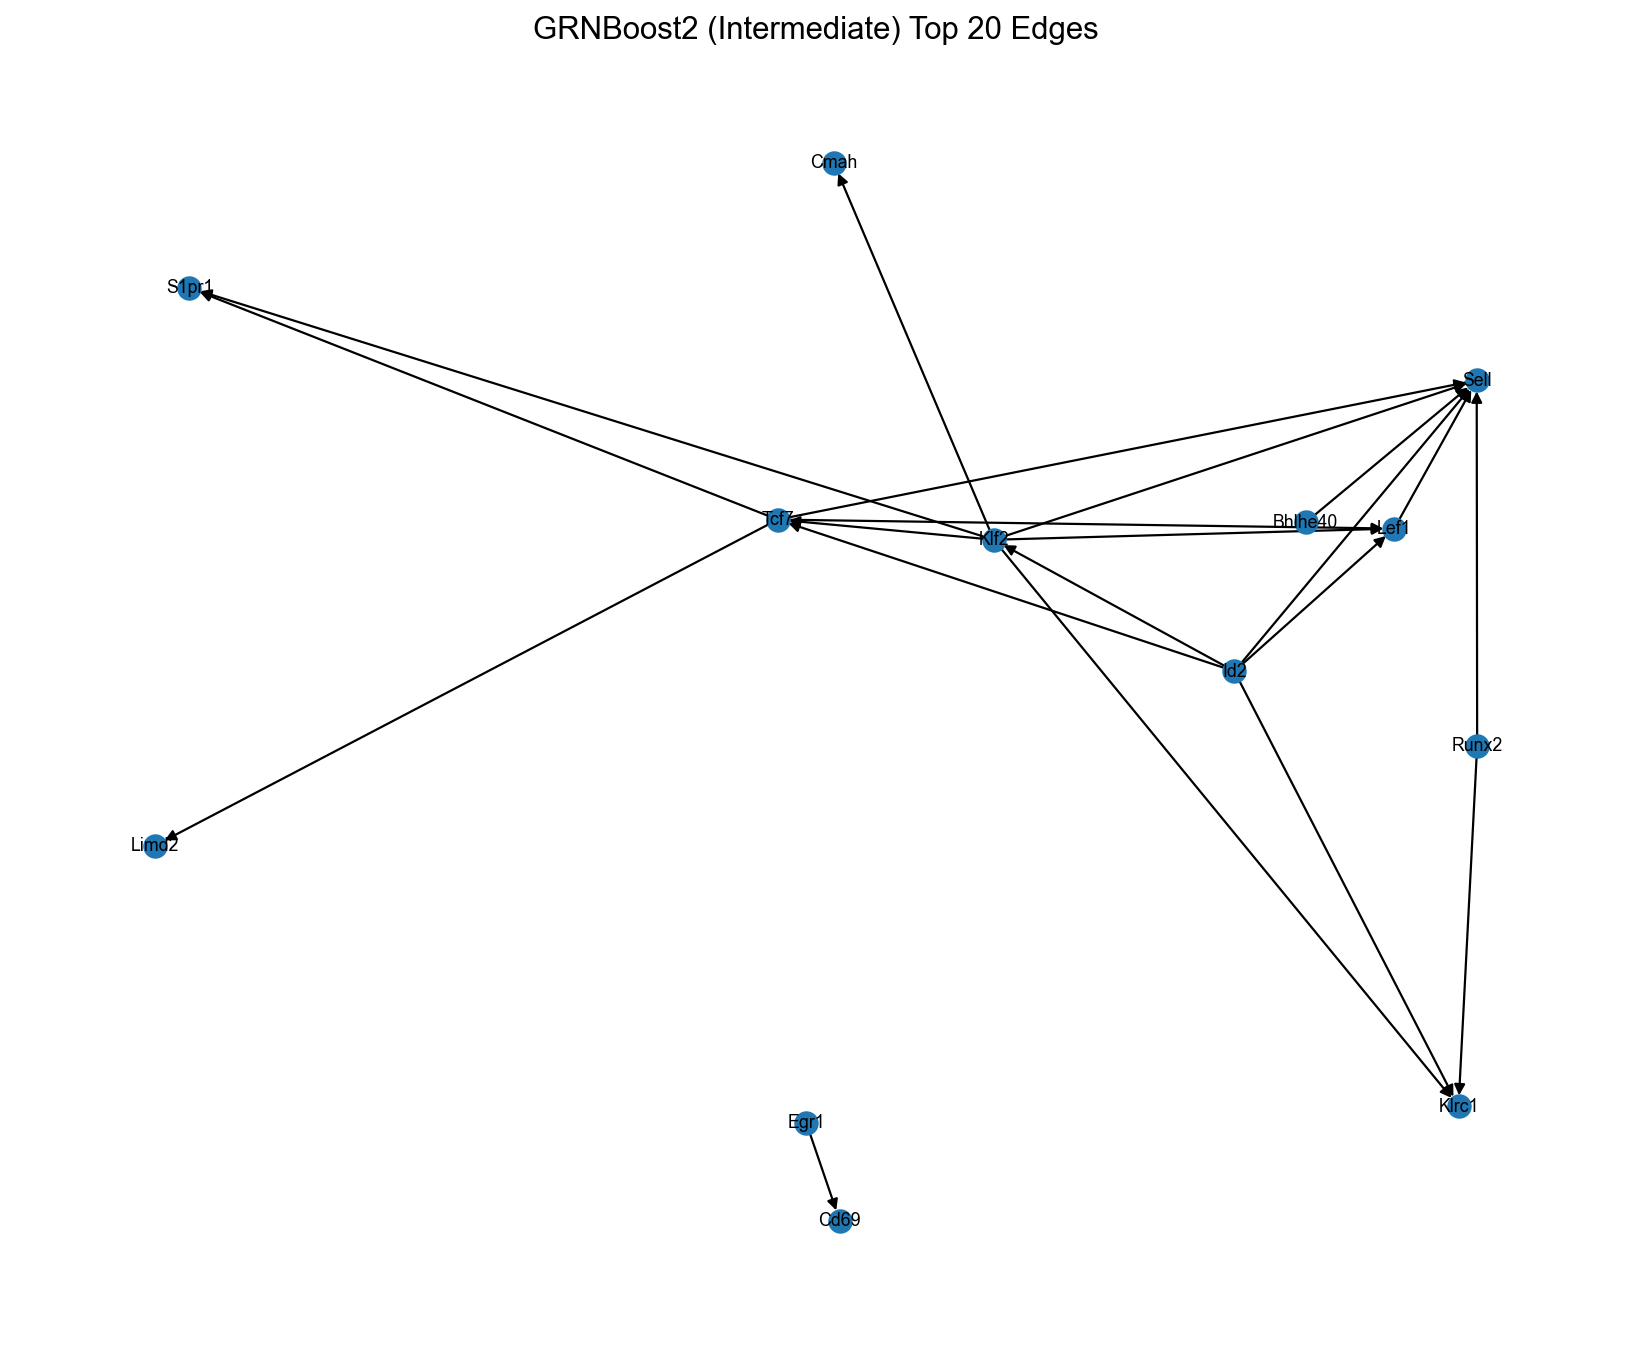

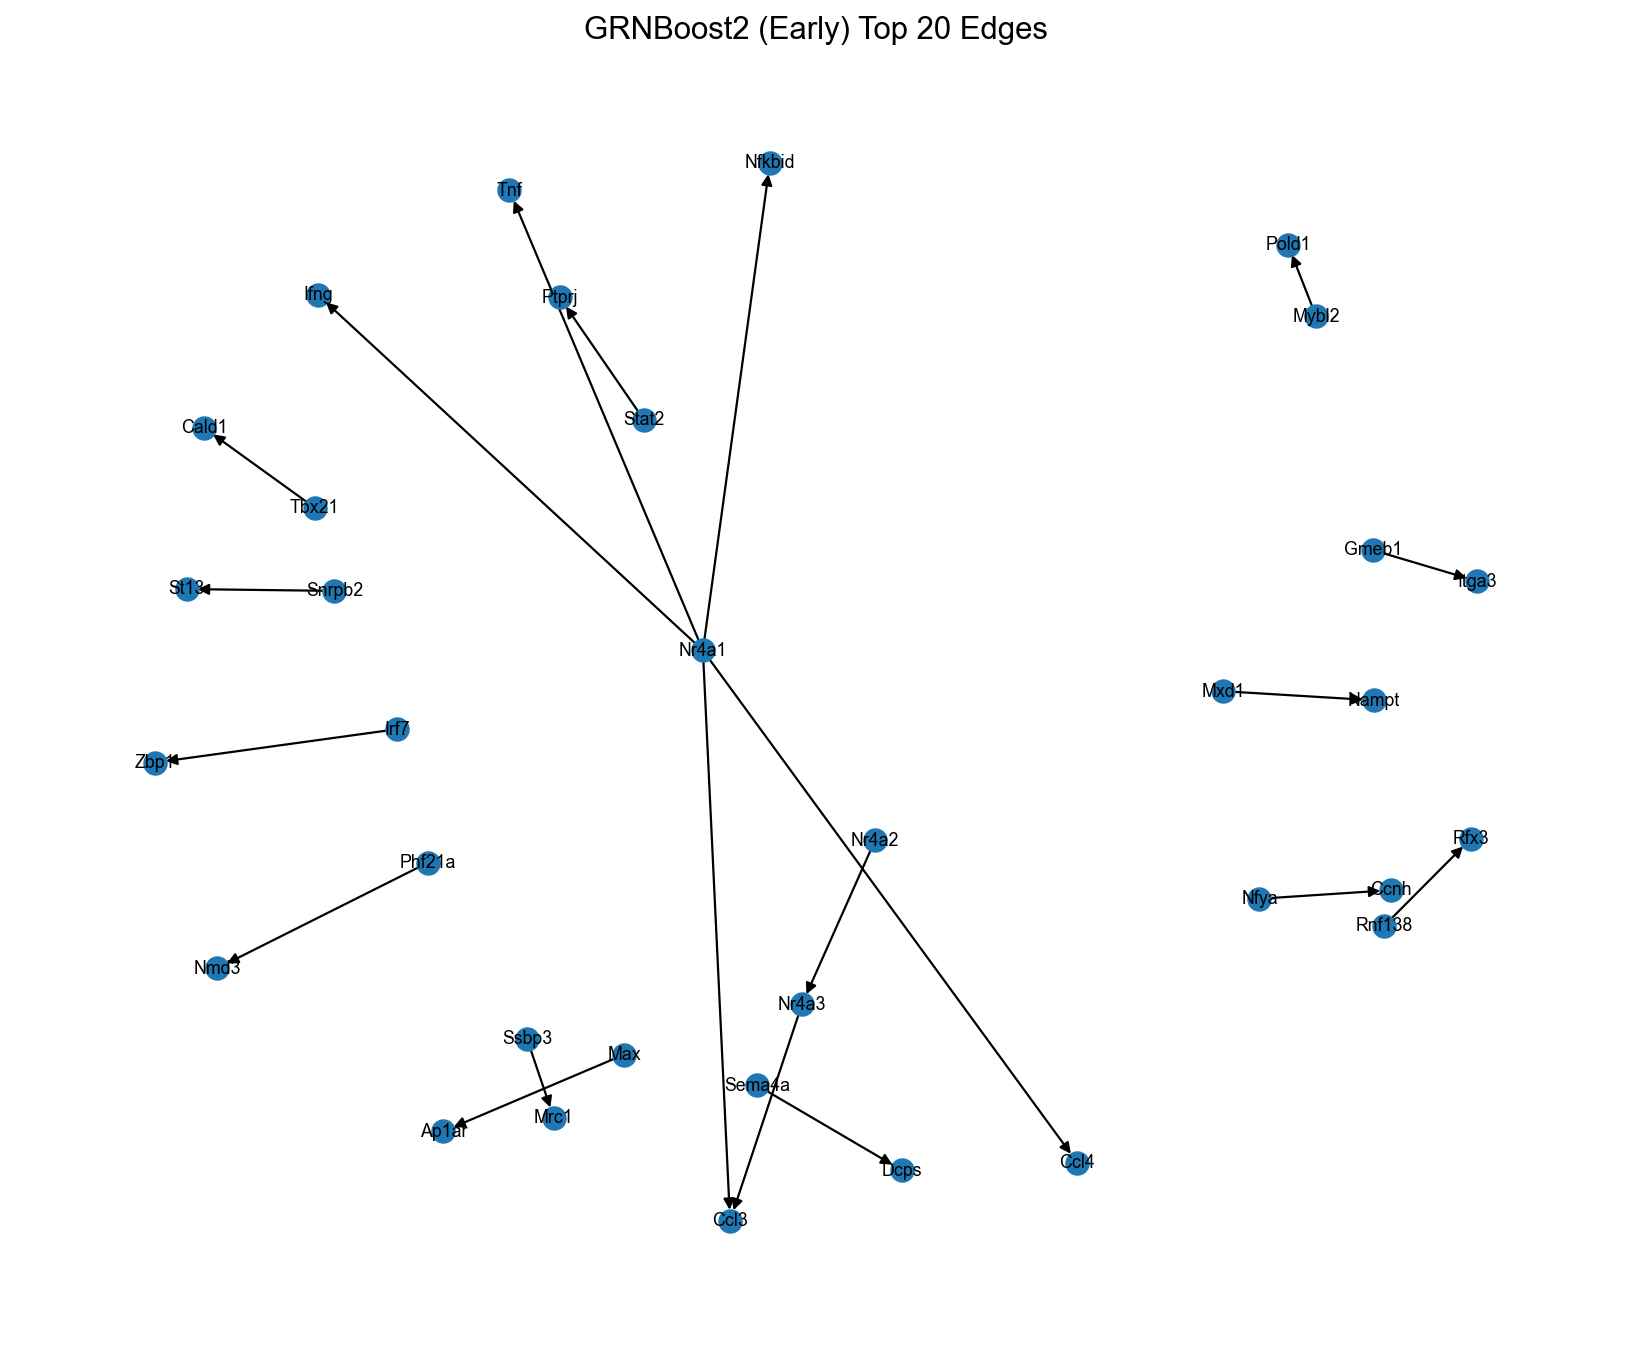

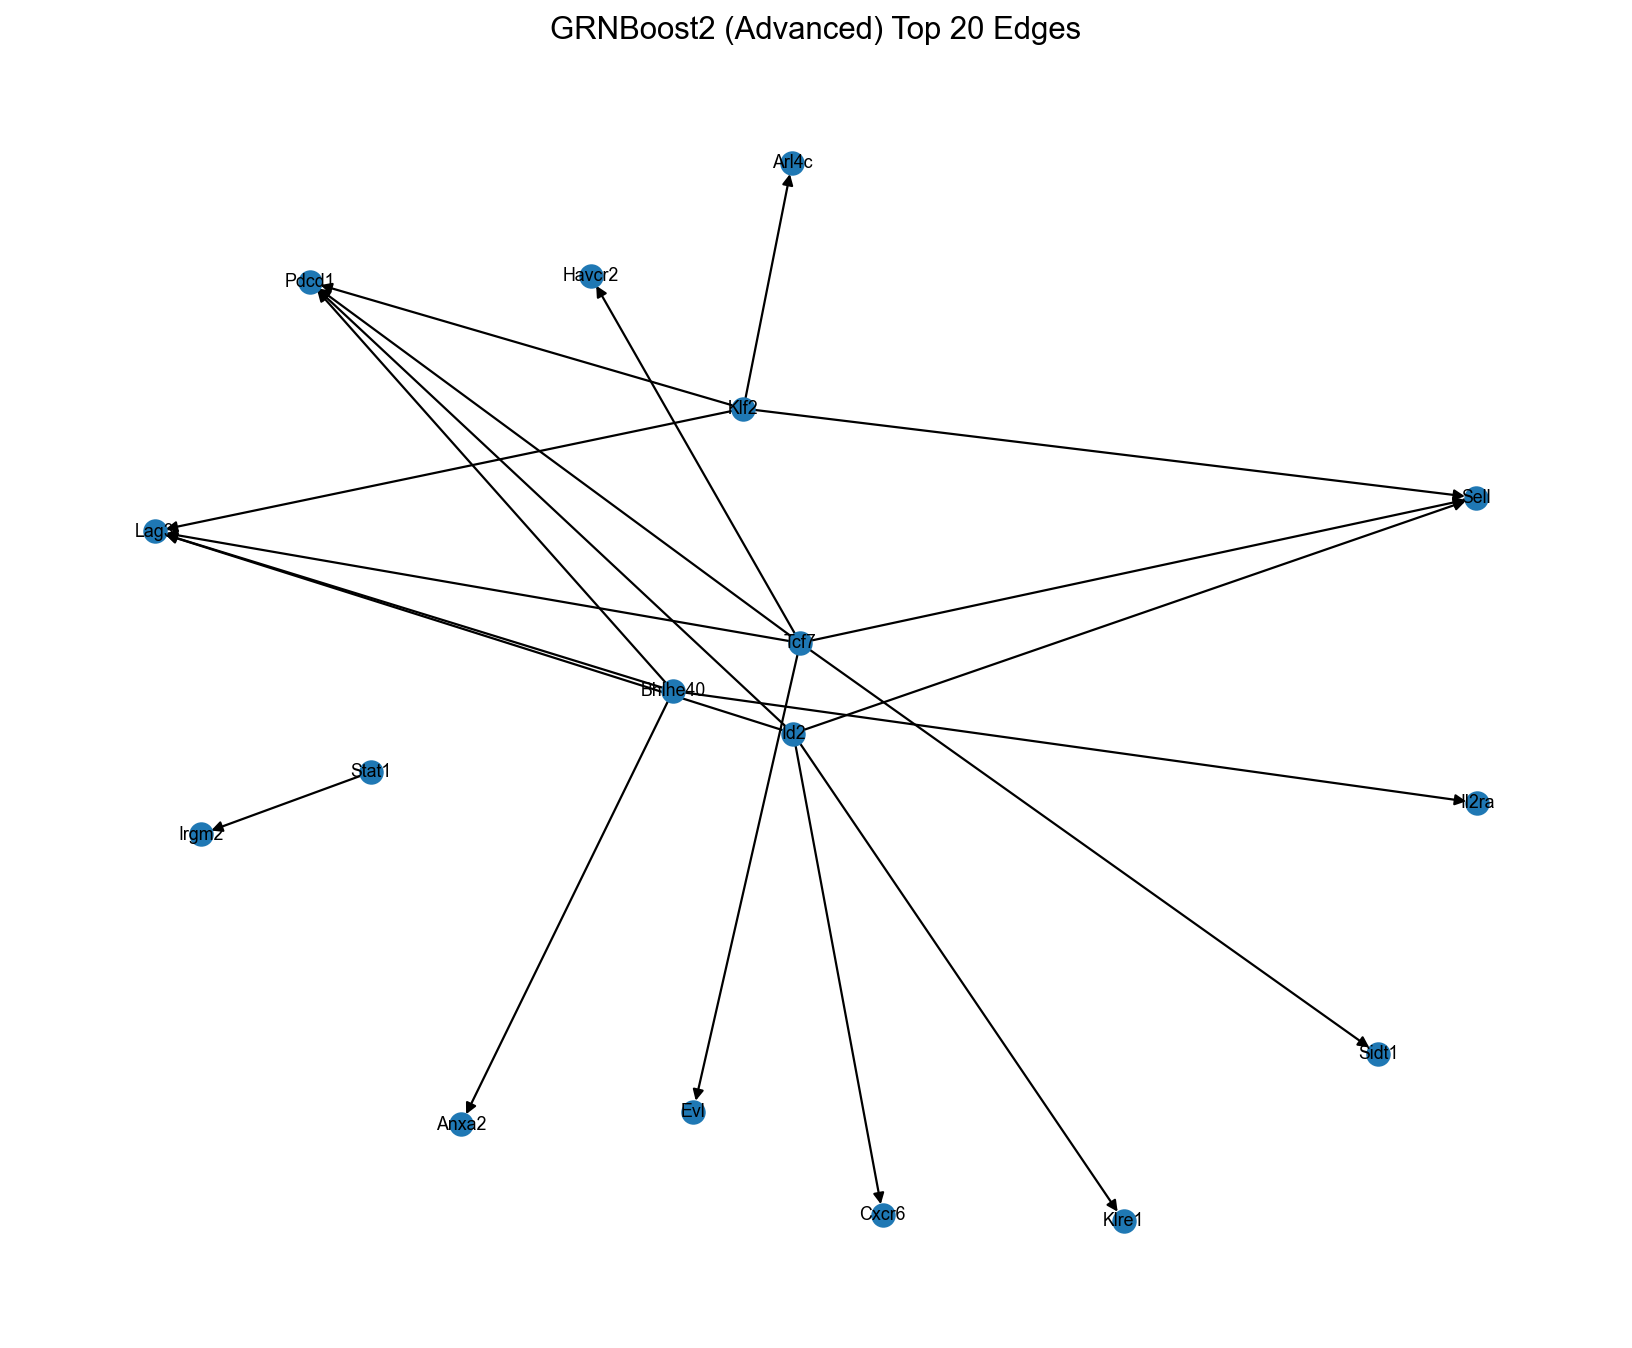

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

num_top_edges = 20  # Number of top edges to plot
for istage, network in networks.items():
    top_edges = network.sort_values('importance', ascending=False).head(num_top_edges)
    G = nx.from_pandas_edgelist(top_edges, 'TF', 'target', edge_attr='importance', create_using=nx.DiGraph())
    plt.figure(figsize=(10,8))
    pos = nx.spring_layout(G, k=0.3, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=100, arrows=True, font_size=8)
    plt.title(f"GRNBoost2 ({istage}) Top {num_top_edges} Edges")
    plt.show()

In [24]:
"""
Circadian gene expression analysis for single-cell RNA-seq data,
with blockwise memory-efficient processing, cosine curve fitting, FDR-corrected statistics,
and heatmap visualization of rhythmic genes.

Author: Selim Romero
Date: 12/16/2025
"""

import os
import time
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.optimize import curve_fit
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------------------
# Suppress warnings for cleaner output
# ------------------------------------------------------------------------------
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# ------------------------------------------------------------------------------
# Circadian fitting for a single gene (cosine model and statistics)
# ------------------------------------------------------------------------------
def estimate_phase_r(Xg_zts, time_step, period=24, test_type='Ftest'):
    """
    Estimate circadian cosine model parameters and statistics for a single gene.

    Xg_zts: list of np.ndarrays for this gene, one array per time point (cells at that time).
    """
    icells = [len(x) for x in Xg_zts]
    num_cells = sum(icells)
    R = np.concatenate(Xg_zts)
    if num_cells < 4 or np.sum([np.mean(x) if len(x) > 0 else 0 for x in Xg_zts]) == 0:
        return np.nan, np.nan, period, np.nan, np.nan, np.nan, np.nan

    time_grid = np.repeat(np.arange(len(Xg_zts)) * time_step, icells)
    R0 = np.array([np.mean(x) if len(x) > 0 else 0 for x in Xg_zts])

    def cos_model(t, acro, amp, mesor):
        return amp * np.cos(2 * np.pi * (t - acro) / period) + mesor

    mean_model_val = np.mean(R)
    max_amp_guess = np.max(R0) - mean_model_val
    max_peak_t_guess = (np.argmax(R0)) * time_step
    p0 = [max_peak_t_guess, max_amp_guess, mean_model_val]
    bounds = ([0, -np.inf, 0], [period, np.inf, np.inf])

    try:
        popt, _ = curve_fit(cos_model, time_grid, R, p0=p0, bounds=bounds, maxfev=5000)
        acrophase, amp, mesor = popt
        SSR_null = np.sum((R - mean_model_val) ** 2)
        SSR_sine = np.sum((R - cos_model(time_grid, *popt)) ** 2)
        if SSR_sine == 0 or len(R) <= 3:
            p_value = np.nan
        else:
            if test_type == 'Ftest':
                d1, d2 = 2, len(R) - 3
                F_stat = ((SSR_null - SSR_sine) / d1) / (SSR_sine / d2)
                p_value = 1 - stats.f.cdf(F_stat, d1, d2)
            else:
                n = num_cells
                logL_null = -0.5 * n * (np.log(2 * np.pi * (SSR_null / n)) + 1)
                logL_sine = -0.5 * n * (np.log(2 * np.pi * (SSR_sine / n)) + 1)
                LRT_stat = -2 * (logL_null - logL_sine)
                p_value = 1 - stats.chi2.cdf(LRT_stat, df=2)
        t_pts = np.arange(len(Xg_zts)) * time_step
        fval = cos_model(t_pts, acrophase, amp, mesor)
        rho, p_value_rho = stats.pearsonr(R0, fval) if np.std(R0) > 0 and np.std(fval) > 0 else (np.nan, np.nan)
    except (RuntimeError, ValueError):
        return np.nan, np.nan, period, np.nan, np.nan, np.nan, np.nan
    return acrophase, amp, period, mesor, p_value, rho, p_value_rho

# ------------------------------------------------------------------------------
# Worker: parallel gene fit and stats
# ------------------------------------------------------------------------------
def _process_gene_optimized(gene_expr_vector, time_masks, time_step, period, test_type='Ftest'):
    Xg_zts = [gene_expr_vector[mask] for mask in time_masks]
    results = estimate_phase_r(Xg_zts, time_step, period=period, test_type=test_type)
    R0 = [np.mean(x) if len(x) > 0 else np.nan for x in Xg_zts]
    return list(results) + R0

# ------------------------------------------------------------------------------
# Main circadian phase estimation (blockwise, memory efficient)
# ------------------------------------------------------------------------------
def sce_circ_phase_estimation(
    adata, tmeta, ct_layer, batch_obs_key='ZT_time', 
    rm_low_conf=True, period=24,
    custom_genelist=None, custom_celltype=None,
    norm_str='lib_size', n_jobs=-1
):
    """
    Runs circadian curve fitting for all genes, all cell types (or subsets).
    For each cell type: processes genes in blocks, fits, collects statistics,
    and exports only rhythmic genes if rm_low_conf is True.

    Returns:
        results_dict[cell_type] = (T1_filtered, T2_filtered)
    """
    import numpy as np
    import pandas as pd
    import scipy

    start_time = time.time()
    tmeta = tmeta.sort_values('times').reset_index(drop=True)
    time_step = np.mean(np.diff(tmeta.times.unique()))
    if norm_str == 'lib_size':
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
    elif norm_str is None:
        print("Using provided data (adata.X). Skipping normalization.")

    all_cell_types = sorted(adata.obs[ct_layer].unique())
    cell_type_list = [ct for ct in (custom_celltype or all_cell_types) if ct in all_cell_types]

    # Store results
    results_dict = {}

    for cell_type in cell_type_list:
        print(f"\nProcessing cell type: {cell_type}")
        cell_type_mask = adata.obs[ct_layer] == cell_type
        gene_list = adata.var_names.tolist() if (custom_genelist is None or custom_genelist == 'all') \
                        else [g for g in custom_genelist if g in adata.var_names]
        if not gene_list:
            continue
        batch_time_labels = tmeta['old_labels'].tolist()
        time_masks = []
        for zt_label in batch_time_labels:
            mask = (cell_type_mask) & (adata.obs[batch_obs_key] == zt_label)
            time_masks.append(mask[cell_type_mask].values)
        if not any(np.any(m) for m in time_masks):
            print(f"Warning: No cells found in any ZT group for {cell_type}. Skipping.")
            continue
        block_size = 500 if adata[cell_type_mask, :].shape[0] < 15000 else 200
        num_genes = len(gene_list)
        num_blocks = int(np.ceil(num_genes / block_size))
        all_results = []
        for block_idx in range(num_blocks):
            start_idx = block_idx * block_size
            end_idx = min((block_idx + 1) * block_size, num_genes)
            block_genes = gene_list[start_idx:end_idx]
            X_block = adata[cell_type_mask, block_genes].X
            if isinstance(X_block, (scipy.sparse.spmatrix, np.matrix)):
                X_block = X_block.toarray()
            results_block = Parallel(n_jobs=n_jobs)(
                delayed(_process_gene_optimized)(X_block[:, i], time_masks, time_step, period)
                for i in range(len(block_genes))
            )
            all_results.extend(zip(block_genes, results_block))
        # Compile results
        col_names_T1 = ["Acrophase", "Amp", "Period", "Mesor", "pvalue", "Sine_corr", "pvalue_corr"]
        T1 = pd.DataFrame([r[1][:7] for r in all_results], columns=col_names_T1)
        T1['Genes'] = [r[0] for r in all_results]
        T2 = pd.DataFrame([r[1][7:] for r in all_results], columns=batch_time_labels)
        T2['Genes'] = [r[0] for r in all_results]
        T1 = T1.dropna(subset=['pvalue', 'pvalue_corr']).reset_index(drop=True)
        T2 = T2[T2['Genes'].isin(T1['Genes'])].reset_index(drop=True)
        if T1.empty: continue
        T1['Abs_Amp'] = T1['Amp'].abs()
        T1['Acrophase_24'] = T1['Acrophase'].apply(lambda x: (x % 24) if not pd.isna(x) else x)
        from statsmodels.stats.multitest import fdrcorrection
        reject, T1['pvalue_adj'] = fdrcorrection(T1['pvalue'])
        reject_corr, T1['pvalue_adj_corr'] = fdrcorrection(T1['pvalue_corr'])
        T1 = T1[["Genes", "Amp", "Abs_Amp", "Mesor", "Acrophase", "Acrophase_24", "Period",
                 "pvalue", "pvalue_adj", "Sine_corr", "pvalue_corr", "pvalue_adj_corr"]]
        confident_mask = (T1.pvalue < 0.05) & (T1.pvalue_corr < 0.05)
        T1_filtered = T1[confident_mask].copy() if rm_low_conf else T1.copy()
        T2_filtered = T2[T2['Genes'].isin(T1_filtered['Genes'])].copy()
        T1_filtered = T1_filtered.sort_values(
            by=["Acrophase_24", "pvalue_adj_corr", "pvalue_adj", "Abs_Amp"],
            ascending=[True, True, True, False]
        ).reset_index(drop=True)
        T2_filtered = T2_filtered.set_index('Genes').loc[T1_filtered['Genes']].reset_index()
        fname_prefix = f"{cell_type}_period_{period}"
        T1_filtered.to_csv(f"{fname_prefix}_macro_circadian_analysis.csv", index=False)
        T2_filtered.to_csv(f"{fname_prefix}_macro_circadian_ZTs.csv", index=False)
        # Export normalized ZT mean table
        T3 = T2_filtered.set_index('Genes').copy()
        zt_cols = T3.columns
        R0_norm = T3[zt_cols].div(T3[zt_cols].values.min(axis=1)[:, np.newaxis], axis=0)
        T3_normalized = R0_norm.reset_index()
        T3_normalized.to_csv(f"{fname_prefix}_macro_circadian_ZTs_normalized.csv", index=False)
        # Add to our results dictionary
        results_dict[cell_type] = (T1_filtered, T2_filtered)

    total_time = time.time() - start_time
    print(f"\nProcessing complete. Total time elapsed: {total_time:.2f} seconds")
    return results_dict

# ------------------------------------------------------------------------------
# Heatmap visualization: show only genes selected by tightening criteria.
# ------------------------------------------------------------------------------
def generate_heatmap_selected_genes(celltype, output_dir='.', period=24, figsize=(6,6)):
    """
    Plots heatmap (zscore) of mean expression only for genes classified as 'confident/rhythmic' in the main analysis for celltype.
    Now enforces a compact, axes-filling, 'lines'-style appearance like MATLAB!
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    import pandas as pd
    import numpy as np

    fname1 = os.path.join(output_dir, f"{celltype}_period_{period}_macro_circadian_analysis.csv")
    fname2 = os.path.join(output_dir, f"{celltype}_period_{period}_macro_circadian_ZTs.csv")
    if not (os.path.exists(fname1) and os.path.exists(fname2)):
        print(f"Heatmap: Filtered results file '{fname1}' or '{fname2}' not found. Cannot make heatmap.")
        return

    T1 = pd.read_csv(fname1)
    T2 = pd.read_csv(fname2)
    # Align/sort genes as in T1
    T2 = T2.set_index('Genes').loc[T1['Genes']].reset_index()
    zt_cols = [c for c in T2.columns if c != 'Genes']
    mean_matrix = T2[zt_cols].to_numpy(dtype=np.float32)
    # Z-score genes (rowwise)
    gene_means = np.nanmean(mean_matrix, axis=1, keepdims=True)
    gene_stds = np.nanstd(mean_matrix, axis=1, keepdims=True) + 1e-10
    data_scaled = (mean_matrix - gene_means) / gene_stds
    gene_names = T2['Genes'].values

    # --- Force a square, compact figure (like MATLAB) ---
    n_genes, n_times = data_scaled.shape
    # Square figure (aspect ratio 1:1), with boxes as lines
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        data_scaled,
        cmap=sns.diverging_palette(240, 10, as_cmap=True),
        yticklabels=gene_names if n_genes <= 20 else False,
        xticklabels=zt_cols,
        mask=np.isnan(data_scaled),
        cbar_kws={'label': 'Z-score'},
        ax=ax
    )

    # Fill axes: thin rectangles (lines), not stretched squares
    ax.set_aspect('auto')
    #plt.tight_layout()
    ax.set_title(f"Mean Gene Expression Heatmap for {celltype}", fontsize=17)
    ax.set_xlabel("Time Batches", fontsize=15)
    ax.set_ylabel("Genes (Sorted by Acrophase)", fontsize=15)
    # Rotate x-axis labels and set font size
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=15)

    fname_prefix = f"{celltype}_period_{period}_rhythmic_heatmap"
    plt.savefig(os.path.join(output_dir, fname_prefix + ".svg"), bbox_inches='tight')
    plt.close()
    print(f"Heatmap saved: {os.path.join(output_dir, fname_prefix + '.svg')}")

# ------------------------------------------------------------------------------
# Main execution block
# ------------------------------------------------------------------------------
# Step 1: Load data!
# adata = sc.read_h5ad("your_file.h5ad")

# Step 2: Zeitgeber time mapping
print("\n--- Performing ZT time conversion ---")
unique_zt = sorted(adata.obs['ZT_time'].unique())
zt_series = adata.obs['ZT_time']
numeric_times = zt_series.str.replace('ZT', '').astype('Int64')
adata.obs['time_numeric'] = numeric_times
zt_time_map = adata.obs.drop_duplicates(subset='ZT_time').set_index('ZT_time')['time_numeric'].reindex(unique_zt)
tmeta = pd.DataFrame({
    'old_labels': unique_zt,
    'new_labels': unique_zt,
    'times': zt_time_map.values
}).sort_values('times').reset_index(drop=True)

output_folder = "sub_pops_circadian_genes"
cell_stage_key = 'tumor_stage'
ct_layer = 'sub_cell_types'
rm_low_conf = True
original_dir = os.getcwd()

print("\n--- Starting Main Analysis Loop over Stages ---")
unique_cell_stages = adata.obs[cell_stage_key].unique()
all_results = {}  # Store all results
original_dir = os.getcwd()

for istage in unique_cell_stages:
    stage_fname = f"stage_{istage}_{output_folder}".replace(' ', '_').replace('/', '_')
    if not os.path.exists(stage_fname):
        os.makedirs(stage_fname)
    os.chdir(stage_fname)
    print(f"\n--- Processing Stage: {istage} in {stage_fname} ---")
    try:
        idx_stage = adata.obs[cell_stage_key] == istage
        adata_sub_stage = adata[idx_stage, :].copy()
        stage_results = sce_circ_phase_estimation(
            adata=adata_sub_stage,
            tmeta=tmeta,
            ct_layer=ct_layer,
            batch_obs_key='ZT_time',
            rm_low_conf=rm_low_conf,
            period=24,
            custom_genelist='all',
            norm_str=None,
            n_jobs=-1
        )
        # Save in global dictionary
        all_results[str(istage)] = stage_results
        print(f"Successfully processed Stage {istage}. Results saved in {stage_fname}")
        for ctype in sorted(adata_sub_stage.obs[ct_layer].unique()):
            generate_heatmap_selected_genes(ctype, output_dir='.', period=24, figsize=(5,5))
    except Exception as err:
        print(f"Error processing stage: {istage}")
        print(f"Error message: {err}")
    finally:
        os.chdir(original_dir)
print("\n--- All stages processed ---")
# Now you can access any result:
# Example: retrieve T1 for stage "early", cell type "CD8+ T cells":
#       all_results["early"]["CD8+ T cells"][0]



--- Performing ZT time conversion ---

--- Starting Main Analysis Loop over Stages ---

--- Processing Stage: Intermediate in stage_Intermediate_sub_pops_circadian_genes ---
Using provided data (adata.X). Skipping normalization.

Processing cell type: CD4+ T cells

Processing cell type: CD8+ T cells

Processing cell type: Cyc. T cells

Processing cell type: DN T cells

Processing cell type: T-Reg cells

Processing cell type: γδ T cells

Processing complete. Total time elapsed: 135.94 seconds
Successfully processed Stage Intermediate. Results saved in stage_Intermediate_sub_pops_circadian_genes
Heatmap saved: .\CD4+ T cells_period_24_rhythmic_heatmap.svg
Heatmap saved: .\CD8+ T cells_period_24_rhythmic_heatmap.svg
Heatmap saved: .\Cyc. T cells_period_24_rhythmic_heatmap.svg
Heatmap saved: .\DN T cells_period_24_rhythmic_heatmap.svg
Heatmap saved: .\T-Reg cells_period_24_rhythmic_heatmap.svg
Heatmap saved: .\γδ T cells_period_24_rhythmic_heatmap.svg

--- Processing Stage: Early in stage

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gene_circadian_results(
    adata, tmeta, T1, T2, gene, color='k', ymax=1,
    figsize=(9,6), savefig=None
):
    """
    Plots violin (raw single cells), ZT means, cosine fit, vertical acrophase line,
    and acrophase value label for one gene.
    Adds F-test p-value, correlation coefficient and correlation t-test p-value in the plot title.
    """
    batch_time_labels = list(tmeta['old_labels'])
    times = list(tmeta['times'])
    if gene not in list(T1['Genes']):
        print(f"Gene {gene} not found in circadian results for this cell type!")
        return
    idx = list(T1['Genes']).index(gene)
    fit_row = T1.iloc[idx]
    T2_row = T2.set_index('Genes').loc[gene, batch_time_labels]
    acrophase = fit_row['Acrophase']
    amp = fit_row['Amp']
    mesor = fit_row['Mesor']
    period = fit_row['Period']
    pval_ftest = fit_row['pvalue']
    pval_corr = fit_row['pvalue_corr']
    sine_corr = fit_row['Sine_corr']

    # For scientific notation if needed
    def format_pval(p):
        if p < 0.001:
            return f'{p:.1e}'
        else:
            return f'{p:.3f}'

    t_grid = np.linspace(min(times), max(times), 300)
    y_fit = amp * np.cos(2 * np.pi * (t_grid - acrophase) / period) + mesor

    # Gather raw single-cell data for violins per ZT
    expr_per_zt = []
    for zt in batch_time_labels:
        zt_mask = (adata.obs['ZT_time'] == zt)
        exprs = adata[zt_mask, gene].X
        if hasattr(exprs, 'toarray'):
            exprs = exprs.toarray().flatten()
        else:
            exprs = np.array(exprs).flatten()
        expr_per_zt.append(exprs)

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    pos = np.array(times)
    # Violin
    parts = ax.violinplot(expr_per_zt, positions=pos, widths=2, showmedians=False, showmeans=False)
    for pc in parts['bodies']:
        pc.set_facecolor('#cccccc')
        pc.set_edgecolor('#666666')
        pc.set_alpha(0.5)
    # Mean line
    ax.plot(pos, T2_row.values, 'o-', color=color, label='Mean at ZT')
    # Cosine fit
    ax.plot(t_grid, y_fit, '-', color='red', lw=2, alpha=0.7, label='Fitted Cosine')
    # Acrophase vertical line
    ax.axvline(acrophase, linestyle='--', color='blue', lw=2, alpha=0.7, label='Acrophase')
    # Annotate acrophase value
    # y_annot = ymax * 0.4
    # x_annot = acrophase-0.0
    # ax.text(x_annot, y_annot, f'Acrophase: {acrophase:.2f}', color='blue',
    #         ha='center', va='bottom', fontsize=13,
    #         rotation=90,  # <--- Add this to rotate (e.g., 90 degrees)
    #         bbox=dict(boxstyle="round,pad=0.2", fc="w", ec="blue", lw=0.8, alpha=0.6))
    # Formatting
    ax.set_xticks(pos)
    ax.set_xticklabels(batch_time_labels, rotation=45, horizontalalignment='right', fontsize=15)
    ax.set_xlabel('Zeitgeber Time', fontsize=15)
    ax.set_ylabel(f'Expression: {gene}', fontsize=15)
    ax.set_ylim(bottom=0, top=ymax)
    ax.legend(fontsize=11, loc='best')
    # -- Title with p-values and correlation --
    ax.set_title(
        f'Circadian pattern: {gene}\n'
        f'F-test p={format_pval(pval_ftest)}, '
        f'Corr. r={sine_corr:.2f}, '
        f't-test p={format_pval(pval_corr)}',
        fontsize=17, pad=16
    )
    plt.tight_layout()
    if savefig is not None:
        plt.savefig(savefig, bbox_inches='tight')
        print(f"Figure saved to: {savefig}")
        plt.close()
    else:
        plt.show()


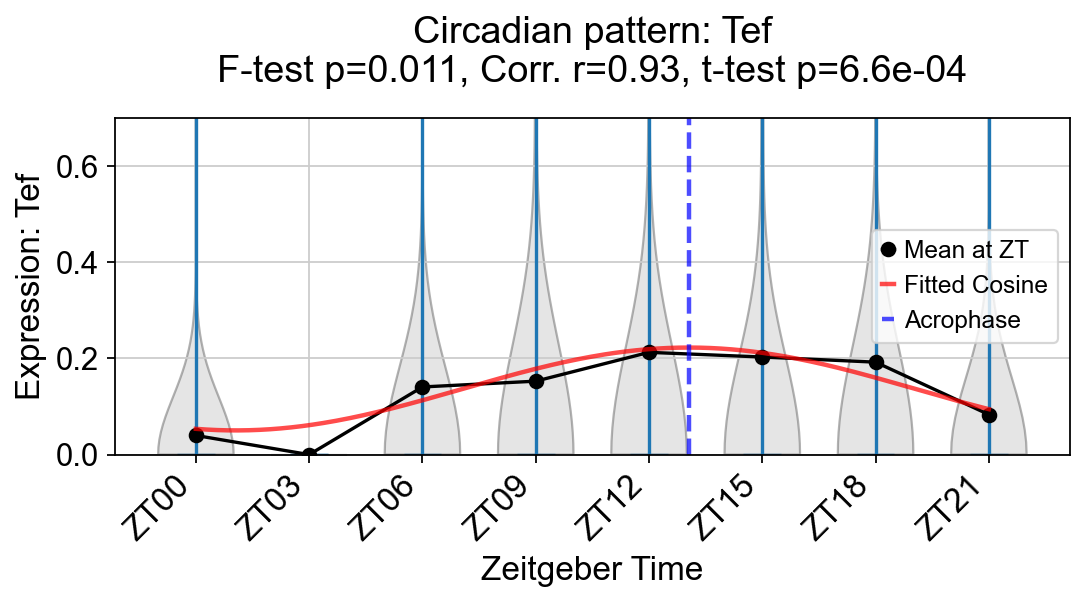

In [44]:
# 1. Choose gene of interest
stage = 'Early'
celltype = 'CD8+ T cells'
T1, T2 = all_results[stage][celltype]
gene = 'Tef'   # or any gene of interest found in T1/T2  like Arntl2
adata_subset = adata[(adata.obs['tumor_stage'] == stage) & (adata.obs['sub_cell_types'] == celltype), :]
plot_gene_circadian_results(adata_subset, tmeta, T1, T2, gene=gene, color='k', ymax = 0.7, figsize=(7,4))

In [48]:
# 1. Choose gene of interest
gene = 'Arntl2'   # or any gene of interest found in T1/T2  like Arntl2
plot_gene_circadian_results(adata_subset, tmeta, T1, T2, gene=gene, color='k', ymax = 0.7, figsize=(5,3.5),savefig="circ_early_tumor_arntl2_cd8tcells.svg")


Figure saved to: circ_early_tumor_arntl2_cd8tcells.svg
